# Advanced NLP Workshop

In this workshop, you will learn a number of advanced NLP techniques, with exercises based on a real-world dataset of tweets on #Telstra and #Optus.

**Installing required libraries.**

Install pyLDAvis library for interactive topic visualization dashboard.

In [1]:
!pip install pyLDAvis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 13.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0

Load libraries.

In [1]:
# Loading primary libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# For text processing
import re
from textblob import TextBlob
import gensim
import logging
import tempfile
from gensim import corpora, models, similarities
from sklearn.feature_extraction.text import CountVectorizer
import pyLDAvis.gensim_models
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Load data

Load the two datasets (Download from LMS)

In [2]:
df_telstra = pd.read_excel("tp7_telco.xlsx", sheet_name='telstra')
df_optus = pd.read_excel("tp7_telco.xlsx", sheet_name='optus')

In [3]:
# display the column names of the datasets
df_optus.columns

Index(['date', 'content', 'likes', 'retweets', 'authorID', 'name', 'gender',
       'followers', 'following', 'nTweets', 'location', 'tweets', 'day'],
      dtype='object')

In [4]:
df_telstra.columns

Index(['date', 'content', 'likes', 'retweets', 'tweets', 'authorID', 'name',
       'gender', 'followers', 'following', 'nTweets', 'location', 'day'],
      dtype='object')

As the first step, we can select a subset of columns required for our analysis. This can be done based on your business requirement.


In [5]:
df_telstra = df_telstra[['day', 'content']]
df_optus = df_optus[['day', 'content']]

In [6]:
df_optus.head()

,day,content
0,2016-01-01,optus ill giv them a try wen i get home is tha...
1,2016-01-01,optus yeah that'll have to do
2,2016-01-01,optus hi are there problems with cable interne...
3,2016-01-01,optus ->ai
4,2016-01-01,optus /waves to esther y


In [8]:
df_telstra.head()

,day,content
0,2016-01-01,telstra runkeeper i went out for a run.
1,2016-01-01,telstra you too :)
2,2016-01-01,telstra here we are no voice service until at ...
3,2016-01-01,home internet down since yesterday. telstra sa...
4,2016-01-01,three times telstra has said there was an erro...


## Preprocessing

Preprocessing applies to both the datasets.  Instead of duplicating the worm ( as we have to do each step twice (for 2 datasets)), we can combine the two datasets, while keeping track of the original dataset. For that, we create a seperate column ('flag') in both datasets, named 'provider' to indicate the source dataset.

In [12]:
# Create a new flag column for both datasets
df_telstra['provider'] = 'telstra'
df_optus['provider'] = 'optus'

In [13]:
df_telstra.head()

,day,content,provider
0,2016-01-01,telstra runkeeper i went out for a run.,telstra
1,2016-01-01,telstra you too :),telstra
2,2016-01-01,telstra here we are no voice service until at ...,telstra
3,2016-01-01,home internet down since yesterday. telstra sa...,telstra
4,2016-01-01,three times telstra has said there was an erro...,telstra


In [14]:
# combine the 2 datasets
df = pd.concat([df_telstra, df_optus], ignore_index=True)

In [15]:
df['provider'].value_counts()

,count
provider,
telstra,25572
optus,12020


Now we run the preprocessing.

In [16]:
# Transform sentences into lowercase
df['content'] = df['content'].str.lower()

In [17]:
# Following command is just to visualize the processed dataframe
df.tail()

,day,content,provider
37587,2016-02-29,optus yes and every day since. i have been run...,optus
37588,2016-02-29,optus hi i've been having trouble with my 4g f...,optus
37589,2016-02-29,optus clever,optus
37590,2016-02-29,optus your store was not aware of the $40 deal...,optus
37591,2016-02-29,jozmosis optus that would disqualify a lot of ...,optus


Remove twitter user ids that are mentioned in the tweet text. We will use [regular expressions ](https://www.w3schools.com/python/python_regex.asp) to do this.  
In applying the regular expression, we use the string in the format r"regular-expression". This is to treat the regex as a raw string. Additional information on this can be found from [this stackoverflow question](https://stackoverflow.com/questions/4780088/what-does-preceding-a-string-literal-with-r-mean).

In [18]:
def remove_twitter_ids(tweet):
  mention_removed_tweet = re.sub(r"(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)", "", str(tweet)) # remove any sequence of characters followed by '@' sign
  spaces_removed = re.sub(r"\s\s+", " ", str(mention_removed_tweet)) # remove multiple spaces
  return spaces_removed

df['content'] = df['content'].apply(remove_twitter_ids)
df.tail()

,day,content,provider
37587,2016-02-29,optus yes and every day since i have been runn...,optus
37588,2016-02-29,optus hi ive been having trouble with my 4g fo...,optus
37589,2016-02-29,optus clever,optus
37590,2016-02-29,optus your store was not aware of the 40 deal ...,optus
37591,2016-02-29,jozmosis optus that would disqualify a lot of ...,optus


In [ ]:
# How does above function works?
# Take any tweet that has mentions in it. e.g., https://twitter.com/DavidLKeating/status/1251253645431144457
twt = "Canada just ordered #masks4all for flights. We need this on all US flights NOW. What are we waiting for @SecElaineChao @AmericanAir @Delta @SouthwestAir @united @AlaskaAir @FAANews ??? @jeremyphoward update"
out_twt = remove_twitter_ids(twt)
print(out_twt)

Canada just ordered masks4all for flights We need this on all US flights NOW What are we waiting for update


### Duplicate removal

It is essential we check for duplicates. Because, the tweets are extracted from Twitter API and it is likely the same tweet repeats multiple times.  
We can utilize pandas drop_duplicates() function. [Link to API](https://pandas.pydata.org/pandas-docs/version/0.24.2/reference/api/pandas.DataFrame.drop_duplicates.html)

In [19]:
# Check duplicate tweets count
duplicate_count = len(df['content'])-len(df['content'].drop_duplicates())
print('duplicate count:', duplicate_count)
print('total records before remove duplicates:', df.shape[0])

duplicate count: 1215
total records before remove duplicates: 37592


In [20]:
# drop duplicates (keep the last tweet of each of the duplicates)
df = df.drop_duplicates(subset='content', keep="first")
print('updated record count:', df.shape[0])

updated record count: 36377


Now we will remove all punctuation, retaining just the text.




In [ ]:
# Remove punctuations
df['content'] = df['content'].str.replace(r'[^\w\s]','')  # This is the use of regular expressions.
df.tail()

<ipython-input-146-667e04136faf>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['content'] = df['content'].str.replace(r'[^\w\s]','')  # This is the use of regular expressions.


,day,content,provider
37587,2016-02-29,optus yes and every day since i have been runn...,optus
37588,2016-02-29,optus hi ive been having trouble with my 4g fo...,optus
37589,2016-02-29,optus clever,optus
37590,2016-02-29,optus your store was not aware of the 40 deal ...,optus
37591,2016-02-29,jozmosis optus that would disqualify a lot of ...,optus


### Stop words and domain related word removal

Now let's conduct further text pre- processing using NLTK library as we did in the first NLP workshop. First, remove stopwords.

In [21]:
#Remove stop words
# Load NLTK library
import nltk

# Download the stopwords to the nltk library
nltk.download('stopwords')

# Load the stopwords
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [22]:
# get the list of all stopwords from the library
stop = stopwords.words('english')

In [39]:
print(stop)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she', "she

Note that the term 'not' is in the stop word list. This will have a negative impact on sentiment analysis. However, if the NLP technique is topic modeling,  there will be no such impact. It is important to keep this mind, drop or retain words depending on the goal of your exercise.  
For this case, we will remove the term 'not' from the stopword list.

In [40]:
stop.remove('not')

ValueError: list.remove(x): x not in list

In [53]:
stop.append("Im")

In [54]:
print(stop)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she', "she

In [55]:
# Remove the words in 'stop' list
def remove_stop_words(tweet):
  tokens = tweet.split()
  stop_removed_tokens = [t for t in tokens if t not in stop]
  convert_to_string = " ".join(stop_removed_tokens)
  return convert_to_string

df['content'] = df['content'].apply(remove_stop_words)
df.tail(5)

,day,content,provider,content_stem
37587,2016-02-29,optus yes every day since running isolation te...,optus,optu ye everi day sinc run isol test 2 week pl...
37588,2016-02-29,optus hi ive trouble 4g last days dont know iv...,optus,optu hi ive troubl 4g last day dont know ive p...
37589,2016-02-29,optus clever,optus,optu clever
37590,2016-02-29,optus store not aware 40 deal 12 month byo dea...,optus,optu store not awar 40 deal 12 month byo deal ...
37591,2016-02-29,jozmosis optus would disqualify lot push notif...,optus,jozmosi optu would disqualifi lot push notif g...


In [56]:
# How above function works?
def remove_stop_words(tweet):
  tokens = tweet.split()
  stop_removed_tokens = [t for t in tokens if t not in stop]
  convert_to_string = " ".join(stop_removed_tokens)
  return convert_to_string

txt = "you are not the first person."
remove_stop_words(txt)

'not first person.'

In [46]:
# For your knowledge: Same above function can be written as a lambda function
# df['content'] = df['content'].apply(lambda x: " ".join(x for x in x.split() if x not in stop))

### Standardization of tweets

We shall use stemming to standardize tweets.  
[Stemming](https://en.wikipedia.org/wiki/Stemming) is the removal of prefix, suffix etc, to derive the base form of a word. We will use the NLTK library.

In [57]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stemming_function(sent):
  word_list = sent.split()
  stemmed_word_list = [stemmer.stem(word) for word in word_list]
  stemmed_sentence = " ".join(stemmed_word_list)
  return stemmed_sentence

df['content_stem'] = df['content'].apply(stemming_function)

In [58]:
# Compare the content vs. stemmed content
df[['content', 'content_stem']].tail(10)

,content,content_stem
37582,optus net pisses,optu net piss
37583,bulldogchris gus10gould juzweezy case point lo...,bulldogchri gus10gould juzweezi case point loo...
37584,leaveforthecup optus yeah good luck,leaveforthecup optu yeah good luck
37585,dragonsfan1988 gus10gould juzweezy foxtel dead...,dragonsfan1988 gus10gould juzweezi foxtel dead...
37586,dragonsfan1988 gus10gould foxtel overpriced nr...,dragonsfan1988 gus10gould foxtel overpr nrl re...
37587,optus yes every day since running isolation te...,optu ye everi day sinc run isol test 2 week pl...
37588,optus hi ive trouble 4g last days dont know iv...,optu hi ive troubl 4g last day dont know ive p...
37589,optus clever,optu clever
37590,optus store not aware 40 deal 12 month byo dea...,optu store not awar 40 deal 12 month byo deal ...
37591,jozmosis optus would disqualify lot push notif...,jozmosi optu would disqualifi lot push notif g...


The stemming has turned term 'optus' to 'optu', thus, stemming has not deemed expected results in this context.  Thereby, we will go ahead with original content without any standardization.   
You may attempt to lemmatize and see if you can improve the results.

## Word frequency analysis

Let us look at the most occuring words and the least occuring words in our tweet dataset.

In [59]:
# Create a word frequency series. (This is a pandas series)
word_frequency = pd.Series(' '.join(df['content']).split()).value_counts()

In [60]:
# Look at the top 10 words (you can write either word_frequency[:10] or word_frequency[0:10]. Both give the same result.)
word_frequency[:10]

,count
telstra,27434
optus,12871
not,3994
internet,3190
phone,2775
get,2668
service,2641
thanks,2210
call,1992
still,1968


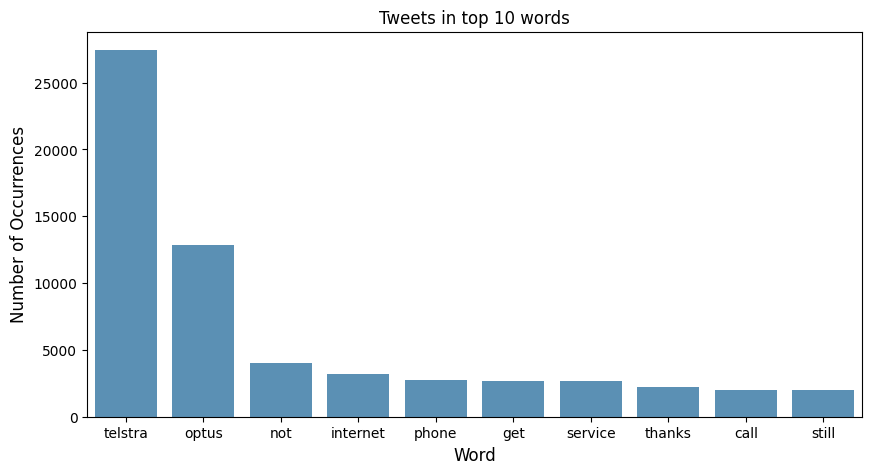

In [61]:
# Visualize the top word counts

word_count  = word_frequency
word_count = word_count[:10,]
plt.figure(figsize=(10,5))
sns.barplot(x=word_count.index, y=word_count.values, alpha=0.8)
plt.title('Tweets in top 10 words')
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Word', fontsize=12)
plt.show()

In [64]:
word_frequency[-10:]

,count
classroom,1
yayy,1
tyrelle123,1
davidmatheson27,1
getyouracttogether,1
yeahright,1
scummiest,1
adslneighbours,1
classico,1
disqualify,1


We will now visualize the text corpus that we created after pre-processing to get insights on the most frequently used words.

In [65]:
from PIL import Image
from wordcloud import WordCloud

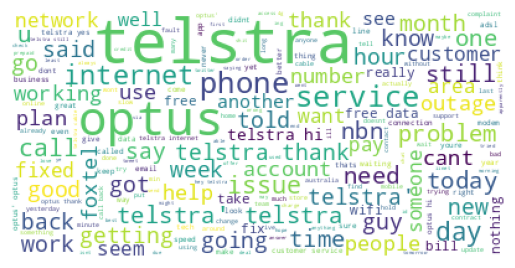

In [66]:
corpus = list(df['content'])

wordcloud = WordCloud(background_color='white', max_words=200, max_font_size=50, random_state=42).generate(str(corpus))

fig = plt.figure(1)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

**Insight**  
From the word cloud we could identify that terms telstra and optus has been mentioned frequently. But this is expected - not so much an insight. Therefore, you may remove high frequent yet non-insightful words alongside the twitter specific words.

### Remove common words

Let's  remove context specific words and the most common words from the tweets.

The tweets extracted are from the hashtags @telstra and @optus, these keywords will appear in most tweets. Let's  add those keywords to the set of words to be removed.  
We can extend the new_words list with those additional keywords, which you may think will be widely used due to the area/domain the tweets were extracted.

In [67]:
# Creating a list of custom stopwords
new_words_to_remove = ["pic", "twitter", "com", "telstra", "optus"]

In [68]:
# Remove common words
# We will use lambda function here.
df['content'] = df['content'].apply(lambda x: " ".join(x for x in x.split() if x not in new_words_to_remove))
df.head(5)

,day,content,provider,content_stem
0,2016-01-01,runkeeper went run,telstra,telstra runkeep went run
1,2016-01-01,,telstra,telstra
2,2016-01-01,voice service least mon box door still open,telstra,telstra voic servic least mon box door still open
3,2016-01-01,home internet since yesterday says fixed 6pm 4...,telstra,home internet sinc yesterday telstra say fix 6...
4,2016-01-01,three times said error porting said completed ...,telstra,three time telstra said error port said comple...


Exercise: try to replicate lambda function above as a python function.

We will re-attempt to compose a frequency appearing word list.

In [69]:
# Create a word frequency series. (This is a pandas series)
word_frequency = pd.Series(' '.join(df['content']).split()).value_counts()

In [70]:
# Look at the top 10 words (you can write either word_frequency[:10] or word_frequency[0:10]. Both give the same result.)
word_frequency[:10]

,count
not,3994
internet,3190
phone,2775
get,2668
service,2641
thanks,2210
call,1992
still,1968
data,1761
cant,1462


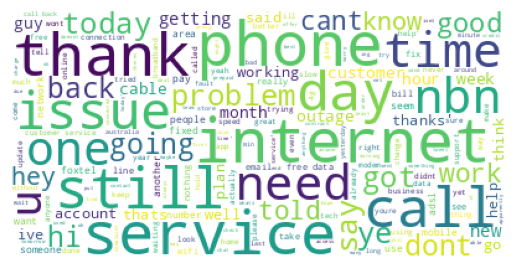

In [71]:
corpus = list(df['content'])

wordcloud = WordCloud(background_color='white', max_words=200, max_font_size=50, random_state=42).generate(str(corpus))

fig = plt.figure(1)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

## Bigrams and Trigrams

The following commands will extract bigrams from the tweet dataset.  
From here onwards, we will isolate tweets for each provider to conduct a comparative analysis.

In [72]:
# Seperate the two datasets by using pandas filtering mechanism.
df_telstra_processed = df.loc[df['provider'] == 'telstra']
df_optus_processed = df.loc[df['provider'] == 'optus']

### Bigrams

We will use CountVectorizer object from sklearn to generate bi-grams and tri-grams. [Link to API](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)  

You may refer [this StackoverFlow explanation](https://stackoverflow.com/questions/24005762/understanding-the-ngram-range-argument-in-a-countvectorizer-in-sklearn) to understand ngram_range parameter.

In [74]:
# This function will generate most frequently occuring Bi-grams
def get_ngrams(corpus, ngram_range=(2, 2)):

    # Create CountVectorizer object from sklearn library with bigrams
    vec1 = CountVectorizer(ngram_range=ngram_range, max_features=2000).fit(corpus)

    # Create BoW feature representation using word frequency
    bag_of_words = vec1.transform(corpus)

    # compute sum of words
    sum_words = bag_of_words.sum(axis=0)

    # create (word, frequency) tuples for bigrams
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec1.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq

Try out an example to see how this  function works.

In [77]:
txts = ['John likes to watch movies', 'Mary likes movies too', 'Mary also likes to watch football games']
get_ngrams(txts, ngram_range=(3, 3))

[('likes to watch', 2),
 ('john likes to', 1),
 ('to watch movies', 1),
 ('mary likes movies', 1),
 ('likes movies too', 1),
 ('mary also likes', 1),
 ('also likes to', 1),
 ('to watch football', 1),
 ('watch football games', 1)]

In [78]:
bigrams_telstra = get_ngrams(df_telstra_processed['content'].tolist(), ngram_range=(2, 2))
bigrams_optus = get_ngrams(df_optus_processed['content'].tolist(), ngram_range=(2, 2))

In [79]:
bigrams_telstra

[('free data', 441),
 ('customer service', 275),
 ('call back', 186),
 ('not working', 182),
 ('data day', 136),
 ('still waiting', 131),
 ('still not', 128),
 ('mobile data', 125),
 ('cable internet', 117),
 ('phone line', 116),
 ('call centre', 115),
 ('home phone', 101),
 ('dont know', 97),
 ('internet connection', 93),
 ('tech support', 93),
 ('live chat', 91),
 ('cant get', 89),
 ('looks like', 88),
 ('case manager', 88),
 ('not sure', 88),
 ('new phone', 84),
 ('24 hours', 82),
 ('not good', 82),
 ('last week', 82),
 ('service status', 81),
 ('cant even', 81),
 ('last night', 78),
 ('internet service', 74),
 ('whats going', 74),
 ('not happy', 73),
 ('phone calls', 67),
 ('doesnt work', 65),
 ('not even', 64),
 ('reference number', 63),
 ('dont want', 63),
 ('phone call', 60),
 ('data today', 60),
 ('status page', 57),
 ('phone internet', 57),
 ('isnt working', 57),
 ('new modem', 54),
 ('get free', 54),
 ('trying get', 54),
 ('unlimited data', 54),
 ('mobile phone', 53),
 ('inte

In [80]:
bigrams_optus

[('customer service', 196),
 ('tech support', 116),
 ('not working', 104),
 ('call back', 104),
 ('fetch tv', 91),
 ('cant get', 78),
 ('last night', 76),
 ('live chat', 72),
 ('still waiting', 72),
 ('cable internet', 71),
 ('still not', 68),
 ('home phone', 64),
 ('please help', 61),
 ('phone internet', 51),
 ('hey guys', 47),
 ('not sure', 46),
 ('internet connection', 45),
 ('not happy', 43),
 ('looks like', 41),
 ('call centre', 39),
 ('24 hours', 39),
 ('mobile data', 39),
 ('new phone', 38),
 ('whats going', 38),
 ('30 mins', 38),
 ('iheartradioau adamlambert', 38),
 ('dont know', 36),
 ('cable broadband', 35),
 ('need help', 35),
 ('phone number', 35),
 ('phone line', 35),
 ('not good', 34),
 ('would like', 34),
 ('sim card', 34),
 ('internet service', 34),
 ('well guess', 34),
 ('last week', 33),
 ('new lambton', 33),
 ('lambton better', 33),
 ('better nothing', 33),
 ('cant even', 32),
 ('wait time', 32),
 ('hi guys', 32),
 ('online chat', 31),
 ('home internet', 31),
 ('next

Convert bigrams of both datasets to a dataframe with column names bi-gram and frequency.

In [82]:
bigrams_telstra_df = pd.DataFrame(bigrams_telstra)
bigrams_telstra_df.columns=["Bi-gram", "Freq"]

bigrams_optus_df = pd.DataFrame(bigrams_optus)
bigrams_optus_df.columns=["Bi-gram", "Freq"]

/tmp/ipython-input-3713100545.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  h.set_xticklabels(h.get_xticklabels(), rotation=90)  # here rotation parameter shows the angle of your x-axis labels


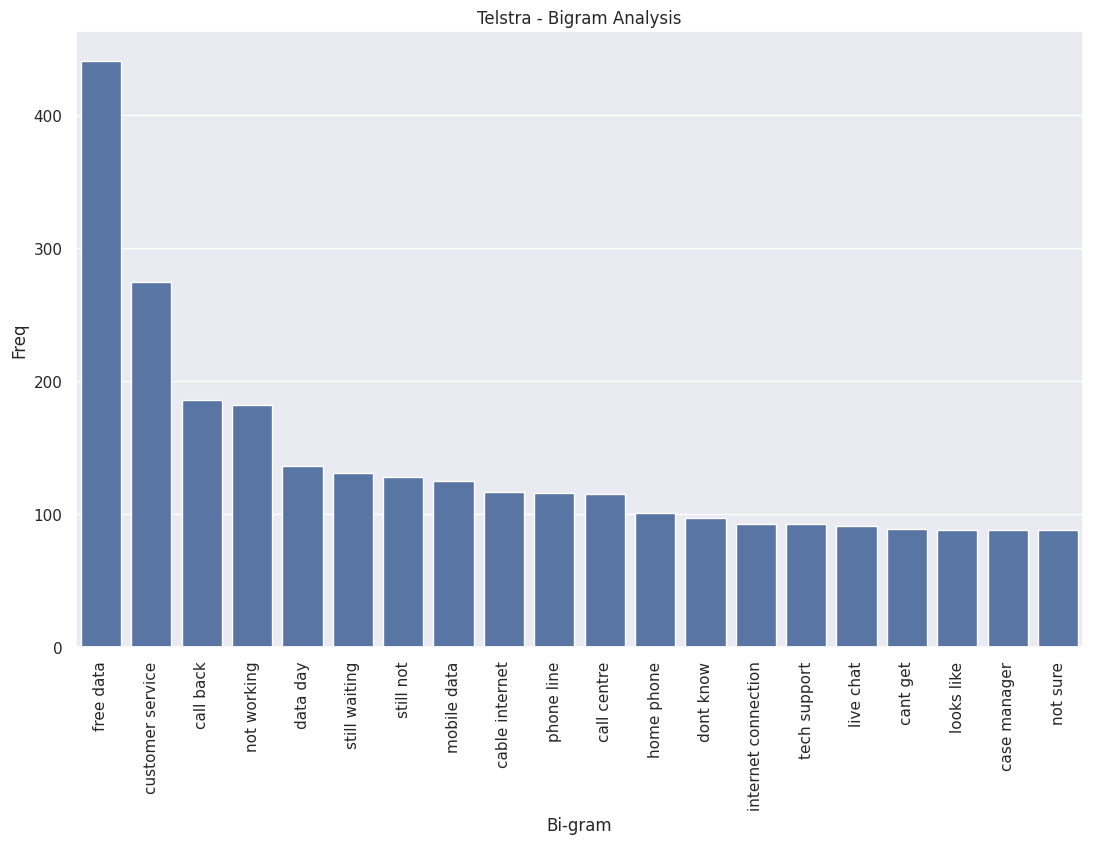

In [83]:
# Barplot of most freq Bi-grams
top_bigrams_to_show = 20

sns.set(rc={'figure.figsize':(13,8)})
h=sns.barplot(x="Bi-gram", y="Freq", data=bigrams_telstra_df[:top_bigrams_to_show])
h.set_xticklabels(h.get_xticklabels(), rotation=90)  # here rotation parameter shows the angle of your x-axis labels
plt.title('Telstra - Bigram Analysis')
plt.show()

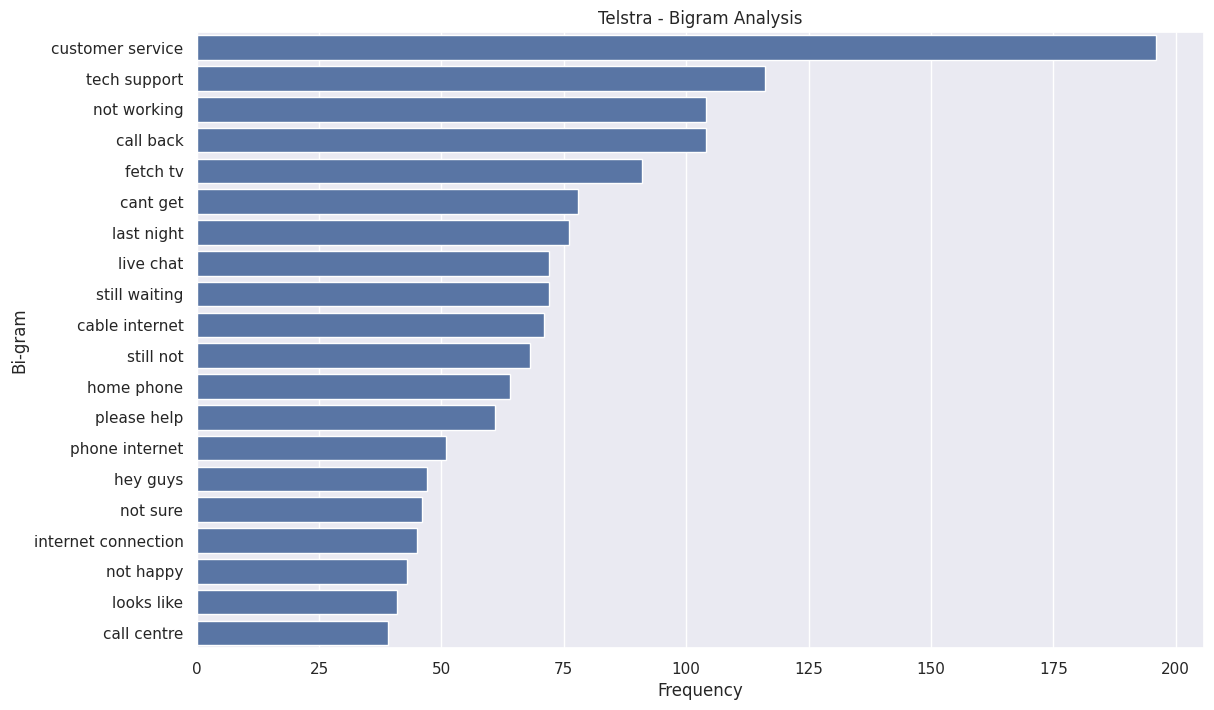

In [85]:
top_bigrams_to_show = 20

sns.set(rc={'figure.figsize':(13,8)})
h = sns.barplot(
    x="Freq",
    y="Bi-gram",
    data=bigrams_optus_df[:top_bigrams_to_show],
    orient="h"
)
plt.title('Optus - Bigram Analysis')
plt.xlabel("Frequency")
plt.ylabel("Bi-gram")
plt.show()

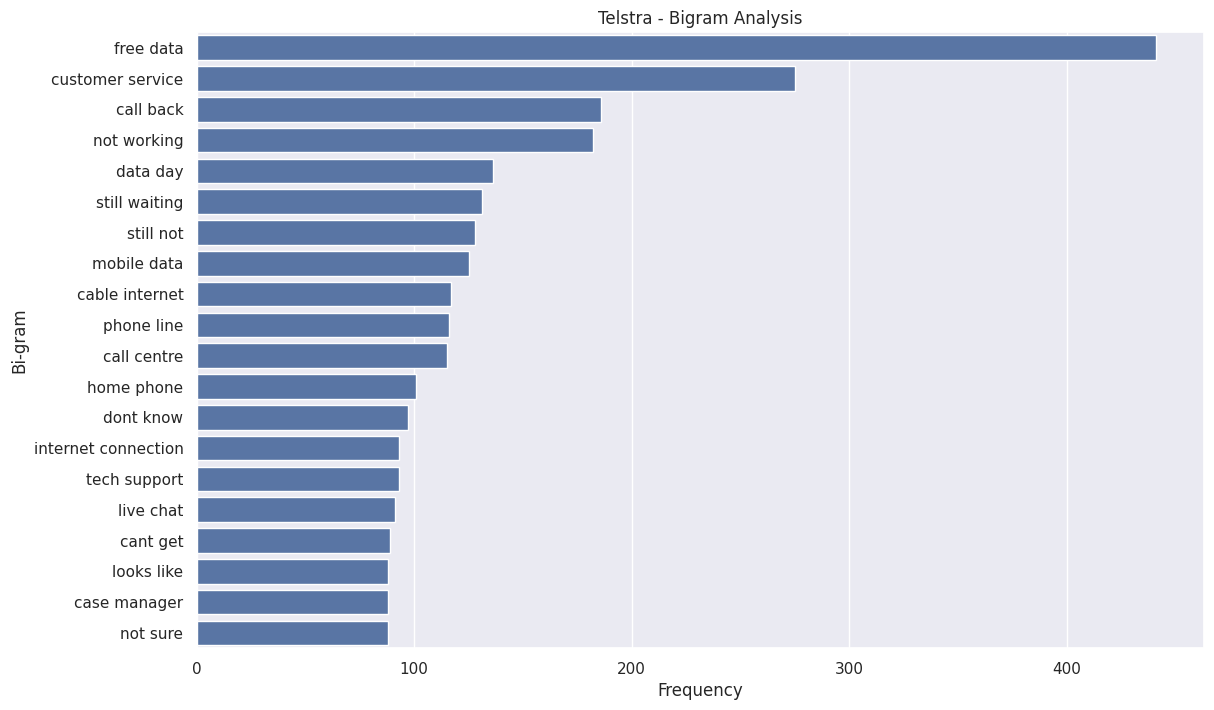

In [86]:
top_bigrams_to_show = 20

sns.set(rc={'figure.figsize':(13,8)})
h = sns.barplot(
    x="Freq",
    y="Bi-gram",
    data=bigrams_telstra_df[:top_bigrams_to_show],
    orient="h"
)
plt.title('Telstra - Bigram Analysis')
plt.xlabel("Frequency")
plt.ylabel("Bi-gram")
plt.show()

**Insights**:  
The bigram 'data day' refers to an event. After a series of outages, Telstra declared a free data day as a compensation. Notice how bigrams can be used to detect such events as well as topics/themes specific to the domain.

/tmp/ipython-input-2333355307.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  h.set_xticklabels(h.get_xticklabels(), rotation=90)


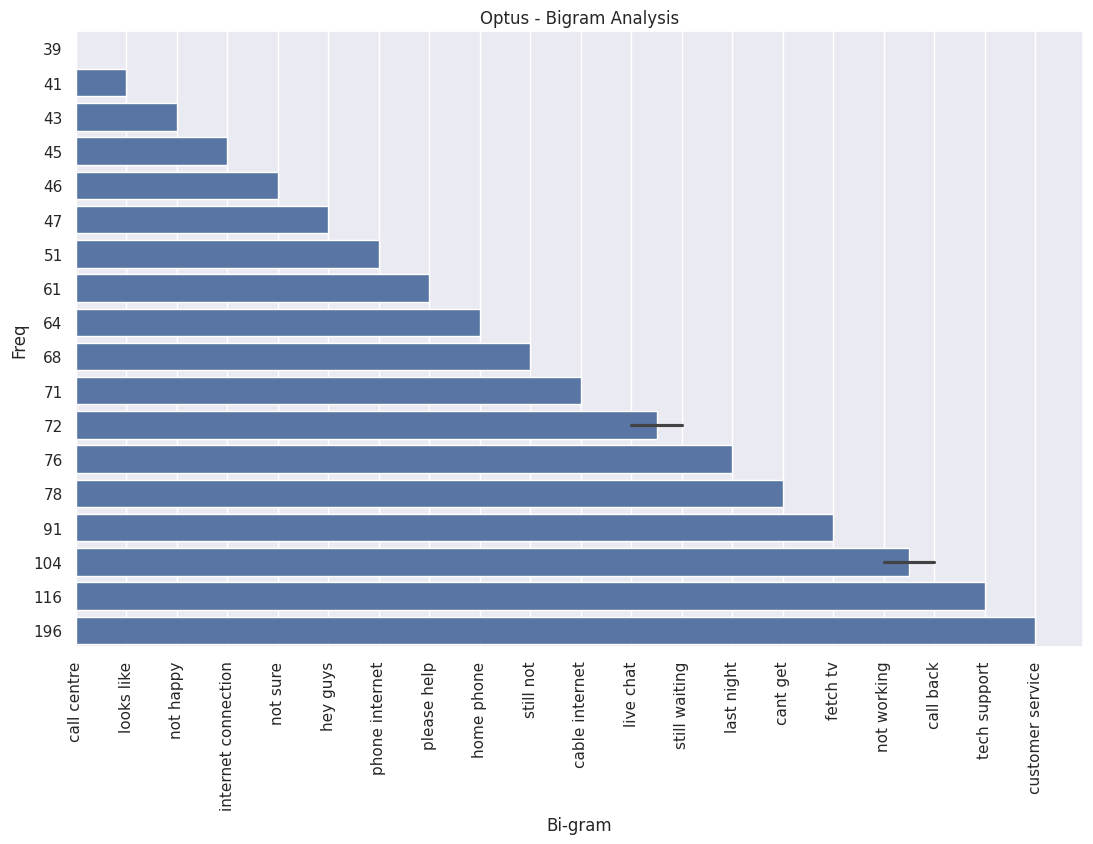

In [92]:
# Barplot of most freq Bi-grams for optus
top_bigrams_to_show = 20

sns.set(rc={'figure.figsize':(13,8)})
h=sns.barplot(x="Bi-gram", y="Freq", data=bigrams_optus_df[:top_bigrams_to_show], orient="h")
h.set_xticklabels(h.get_xticklabels(), rotation=90)
plt.title('Optus - Bigram Analysis')
plt.show()

**Insights:**  
Observe that in Optus dataset, there are many words related to sport which were not prominent in Telstra data. Bigram frequencies can be used to differentiate and compare topics of interest.

### Trigrams

Let's now attempt trigrams.

In [87]:
trigrams_telstra = get_ngrams(df_telstra_processed['content'].tolist(), ngram_range=(3, 3))
trigrams_optus = get_ngrams(df_optus_processed['content'].tolist(), ngram_range=(3, 3))

Convert tri-grams of both datasets to a dataframe with column names tri-gram and frequency.

In [88]:
trigrams_telstra_df = pd.DataFrame(trigrams_telstra)
trigrams_telstra_df.columns=["Tri-gram", "Freq"]

trigrams_optus_df = pd.DataFrame(trigrams_optus)
trigrams_optus_df.columns=["Tri-gram", "Freq"]

/tmp/ipython-input-160570076.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  h.set_xticklabels(h.get_xticklabels(), rotation=90)


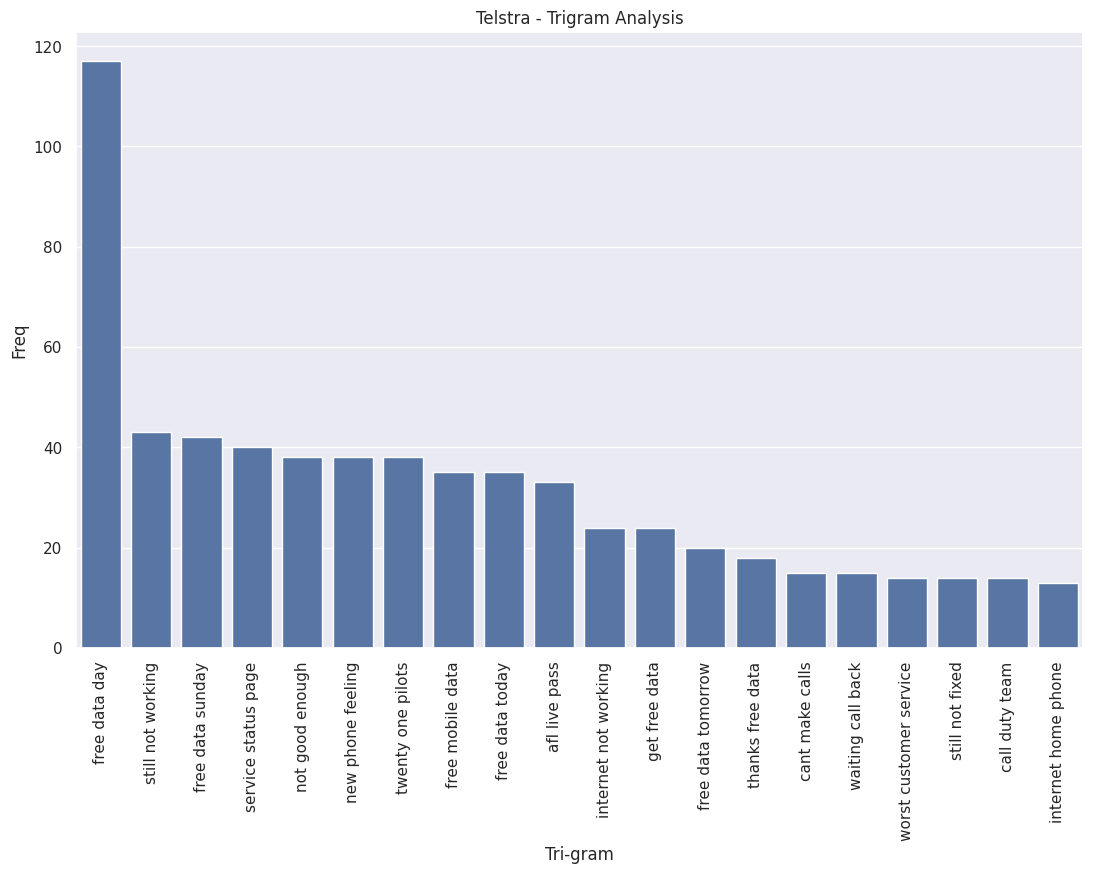

In [91]:
# Barplot of most freq Tri-grams
top_trigrams_to_show = 20

sns.set(rc={'figure.figsize':(13,8)})
h=sns.barplot(x="Tri-gram", y="Freq", data=trigrams_telstra_df[:top_trigrams_to_show])
h.set_xticklabels(h.get_xticklabels(), rotation=90)
plt.title('Telstra - Trigram Analysis')
plt.show()

<ipython-input-178-2de30eaf1ba9>:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  h.set_xticklabels(h.get_xticklabels(), rotation=90)


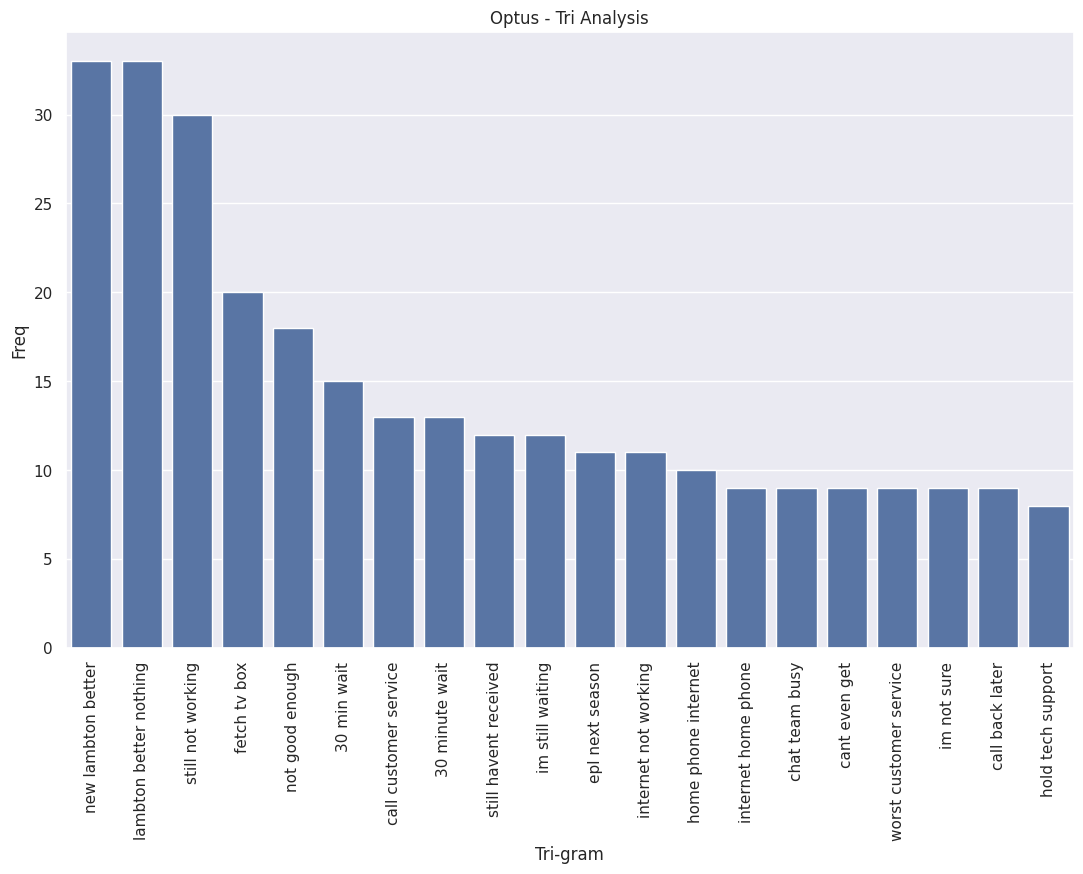

In [ ]:
# Barplot of most freq Tri-grams
top_trigrams_to_show = 20

sns.set(rc={'figure.figsize':(13,8)})
h=sns.barplot(x="Tri-gram", y="Freq", data=trigrams_optus_df[:top_trigrams_to_show])
h.set_xticklabels(h.get_xticklabels(), rotation=90)
plt.title('Optus - Tri Analysis')
plt.show()

Can you determine new insights from Trigram plots?

## Temporal Analysis

Now let's attempt to explore temporal patterns in the two datasets.

In [93]:
# Group the twitter datasets based on the date field and get the count per each day.
df_telstra_date_wise = df_telstra_processed.groupby(['day'])['content'].count().reset_index(name='tweet_count_telstra').set_index('day')
df_optus_date_wise = df_optus_processed.groupby(['day'])['content'].count().reset_index(name='tweet_count_optus').set_index('day')

In [94]:
df_telstra_date_wise.head()

,tweet_count_telstra
day,
2016-01-01,147
2016-01-02,518
2016-01-03,418
2016-01-04,696
2016-01-05,257


In [95]:
df_optus_date_wise.tail()

,tweet_count_optus
day,
2016-02-25,160
2016-02-26,220
2016-02-27,140
2016-02-28,100
2016-02-29,155


When plotting with python, we can change the size of the plot and save it as a figure in your workspace.  
* Change size: plt.figure(figsize=(width, length)) # width and length are in inches  
* Save the image: plt.savefig(filename, dpi)  # dpi is the resolution in pixels

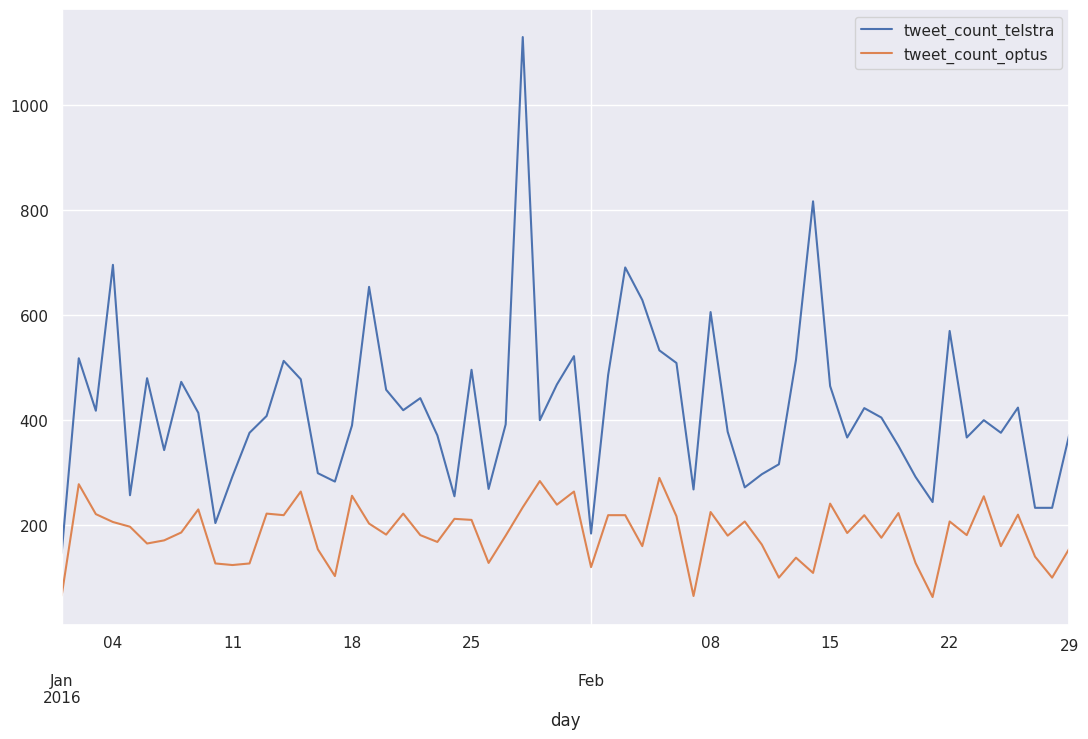

In [96]:
ax = df_telstra_date_wise.plot()
df_optus_date_wise.plot(ax=ax)
plt.savefig('temporal_analysis_v2.png', dpi=800)

Output image is saved in files tab. You can right click on the image and download it to your computer for further analysis.

Insights: How would you describe the two line plots? Any actionable insights?  
Exerciese: Go through the actual Telstra dataset on 2018-01-28, can you explain this spike in tweet count?

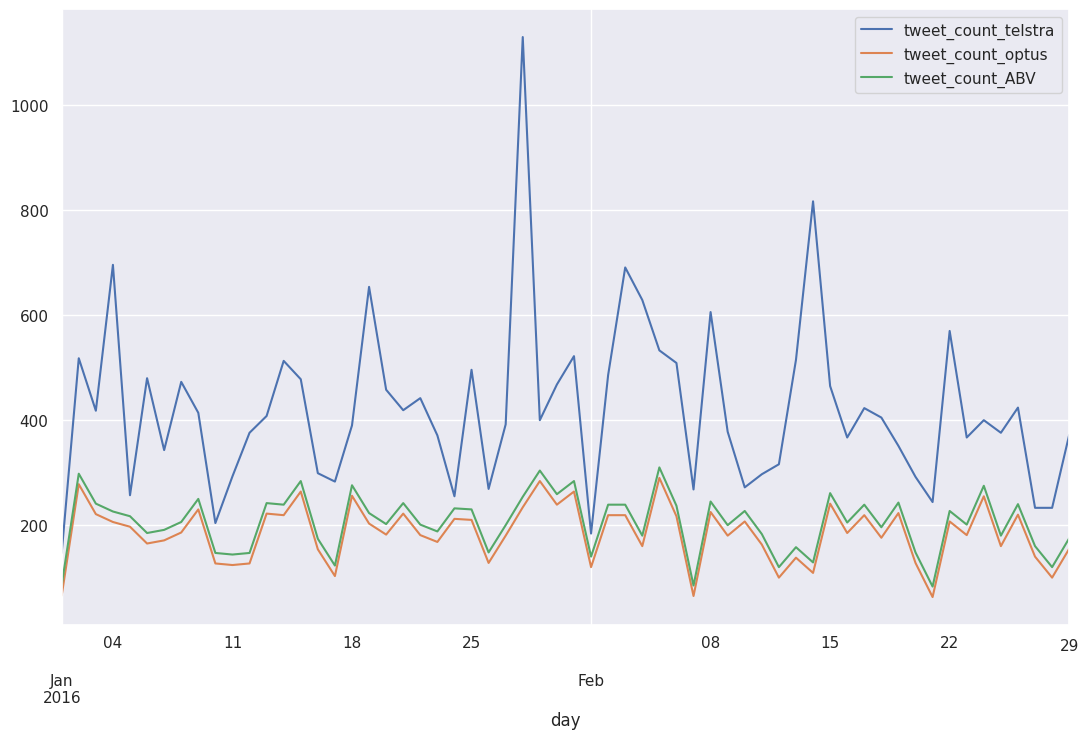

In [97]:
# this is a helper code if you have 3 or more dataframes to compare with.
df_ABC_date_wise =df_optus_date_wise.copy()
df_ABC_date_wise['tweet_count_ABV'] = df_ABC_date_wise['tweet_count_optus'] + 20
del df_ABC_date_wise['tweet_count_optus']

ax = df_telstra_date_wise.plot()
df_optus_date_wise.plot(ax=ax)
df_ABC_date_wise.plot(ax=ax)
plt.savefig('temporal_analysis_v3.png', dpi=800)

In [98]:
filtered_df = df_telstra_date_wise.loc['2016-01-28']
filtered_df

,2016-01-28
tweet_count_telstra,1130


In [99]:
'\n'.join(df_telstra[df_telstra['day']=='2016-01-28']['content'])

'telstra i\'m sorry you have to go through that. ironically i\'m a part of it\ntelstra would you agree with ivan that dylan is indeed the greatest memer in telstra twitter support?\nimmunity_sarina telstra nature of the business y they aren\'t the worst, but when it\'s bad, it is bad.\nnatogamertv immunity_sarina telstra while streaming. rip\nnatogamertv immunity_sarina telstra cable at my parents\' place was with them. meant to get 20 upload, got 1.8. consistent d/c every hr\niamcyberwaste immunity_sarina kidkerrigan i went a month in the optus to telstra changeover. i been there too y\ntelstra coilections has steph died? she hasn\'t tweeted in 14 minutes! will tristan get an answer? find out next time on telstra twitter.\nhey telstra your 24x7 chat is right now a 24x7 fail. 2 hours, 20 mins. tiredandcranky\ntelstra coilections oh wait yes she has and tristan got an answer\nbtgeezy telstra untag you miserable human being\ntelstra no but your organisation has a unique effect on me. per

Bit of exploration revealed this: https://www.itnews.com.au/news/embarrassing-human-error-behind-national-telstra-outage-414836


## Sentiment Analysis

Analyse sentiments for each tweet, aggregate into the sentiment of particular day and derive a sentiment timeline.

In [100]:
# Extract sentiments from the tweets (This should take some time because we run this to the entire dataset.)
df['sentiment'] = df['content'].apply(lambda x: TextBlob(x).sentiment.polarity)

In [101]:
# Display first 50 tweets with respective sentiment value
df[['content', 'sentiment']].head(50)

,content,sentiment
0,runkeeper went run,0.000000
1,,0.000000
2,voice service least mon box door still open,-0.150000
3,home internet since yesterday says fixed 6pm 4...,0.100000
4,three times said error porting said completed ...,0.000000
5,last six weeks ed continually porting number a...,0.000000
6,already,0.000000
7,per tweet service restored 6pm 4th jan ridiculous,-0.333333
8,bilis nang hahahaha,0.200000
9,awesome thanks nye text worried missing offers...,0.220000


Again we will conduct invididual analysis for both telcom providers.

In [102]:
df_telstra_processed = df.loc[df['provider'] == 'telstra']
df_optus_processed = df.loc[df['provider'] == 'optus']

Aggregate the sentiment value (using mean) for each provider

In [103]:
df_telstra_processed

,day,content,provider,content_stem,sentiment
0,2016-01-01,runkeeper went run,telstra,telstra runkeep went run,0.000
1,2016-01-01,,telstra,telstra,0.000
2,2016-01-01,voice service least mon box door still open,telstra,telstra voic servic least mon box door still open,-0.150
3,2016-01-01,home internet since yesterday says fixed 6pm 4...,telstra,home internet sinc yesterday telstra say fix 6...,0.100
4,2016-01-01,three times said error porting said completed ...,telstra,three time telstra said error port said comple...,0.000
...,...,...,...,...,...
25567,2016-02-29,stop mobile redirecting home phone windows pho...,telstra,telstra stop mobil redirect home phone window ...,0.000
25568,2016-02-29,gg ed thegmunay,telstra,gg telstra ed thegmunay,0.000
25569,2016-02-29,get shit together ffs twice today internet died,telstra,telstra get shit togeth ff twice today interne...,-0.200
25570,2016-02-29,yeh technical error explanation told one date ...,telstra,telstra yeh technic error explan told one date...,0.125


In [104]:
df_telstra_processed.groupby(['day'])['sentiment'].mean()

,sentiment
day,
2016-01-01,0.003838
2016-01-02,0.028647
2016-01-03,0.066871
2016-01-04,0.043939
2016-01-05,0.032759
2016-01-06,0.009095
2016-01-07,0.016708
2016-01-08,0.031807
2016-01-09,0.038777


In [105]:
df_senti_telstra_date_wise = df_telstra_processed.groupby(['day'])['sentiment'].mean().reset_index(name='mean_sentiment_telstra').set_index('day')
df_senti_optus_date_wise = df_optus_processed.groupby(['day'])['sentiment'].mean().reset_index(name='mean_sentiment_optus').set_index('day')

Plot sentiment over time.

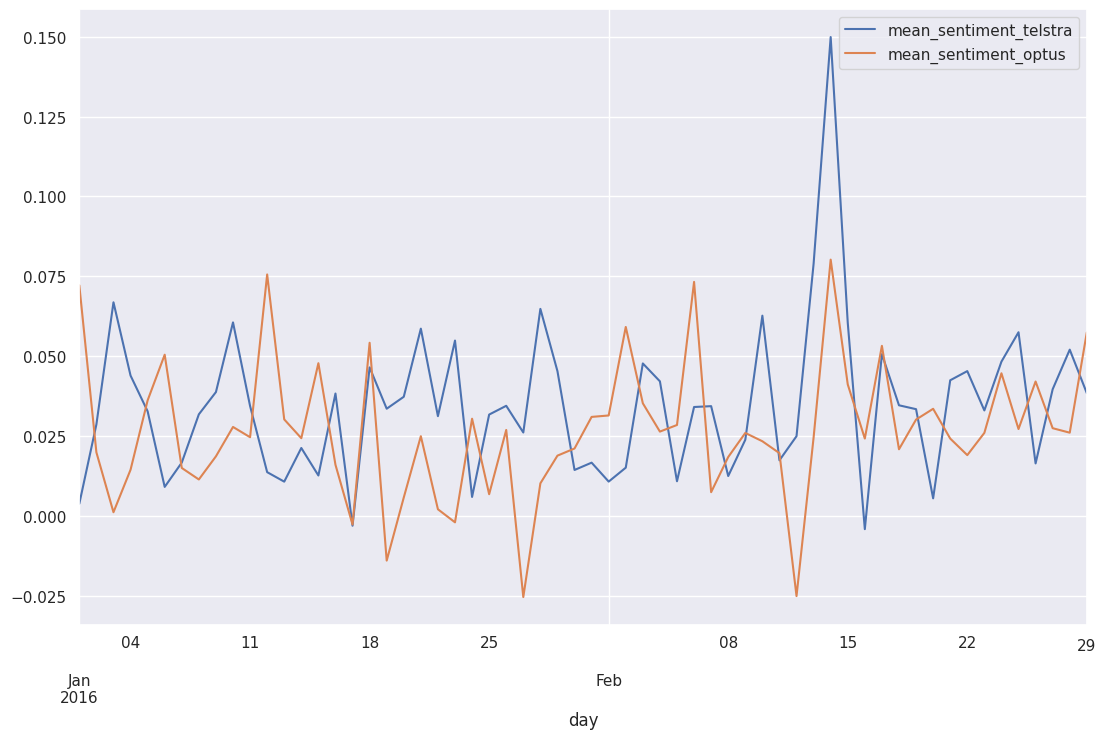

In [106]:
# Plot twitter sentimet timeline over each provider
ax = df_senti_telstra_date_wise.plot()
df_senti_optus_date_wise.plot(ax=ax)
plt.savefig('temporal_sentiment_v2.png', dpi=800)

**Insights:**   
When deriving insights you can refer to days with significant sentiment scores (peaks) and explore the tweets to identify what event has led to positive/negative sentiment.

## Topic Modeling

We will conduct a topic modeling for one of the twitter datasets here (Telstra).  
It is possible to conduct topic modeling using single words, bigrams, trigrams or n-grams.  
Will be using a topic modeling algorithm named - LDA (Latent Dirichlet Allocation) for this task.

In [129]:
# Setting up the environment for LDA algorithm.

TEMP_FOLDER = tempfile.gettempdir()
print('Folder "{}" will be used to save temporary dictionary and corpus.'.format(TEMP_FOLDER))
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

Folder "/tmp" will be used to save temporary dictionary and corpus.


In [130]:
# Filter the dataset of the telstra only.
df_telstra_processed = df.loc[df['provider'] == 'telstra']

Now we will create the text corpus.  


In [131]:
# Convert the tweets as the text corpus.
corpus = list(df_telstra_processed['content'])

In [126]:
corpus[:5]

['runkeeper went run',
 '',
 'voice service least mon box door still open',
 'home internet since yesterday says fixed 6pm 4jan five days areyoujoking pleaseexplain',
 'three times said error porting said completed wasnt cancelled']

In [132]:
# Tokenization
telstra_texts = [[word for word in str(document).split()] for document in corpus]

In [112]:
telstra_texts[:5]

[['runkeeper', 'went', 'run'],
 [],
 ['voice', 'service', 'least', 'mon', 'box', 'door', 'still', 'open'],
 ['home',
  'internet',
  'since',
  'yesterday',
  'says',
  'fixed',
  '6pm',
  '4jan',
  'five',
  'days',
  'areyoujoking',
  'pleaseexplain'],
 ['three',
  'times',
  'said',
  'error',
  'porting',
  'said',
  'completed',
  'wasnt',
  'cancelled']]

In [119]:
# Create a dictionary based on the tokanized words of all the tweets.
dictionary = corpora.Dictionary(telstra_texts)

# Save the above dictionary as a local file for LDA model to access.
dictionary.save(os.path.join(TEMP_FOLDER, 'telstra.dict'))

When creating the dictionary, each tweet (document) is alphabetically sorted before composing the dictionary.

In [116]:
print(telstra_texts[0])
print('alphabetically sorted', sorted(telstra_texts[0]))

['runkeeper', 'went', 'run']
alphabetically sorted ['run', 'runkeeper', 'went']


In [117]:
print(telstra_texts[1])
print('alphabetically sorted', sorted(telstra_texts[1]))

[]
alphabetically sorted []


In [120]:
# Print the dictionary
print(dictionary.token2id)

{'run': 0, 'runkeeper': 1, 'went': 2, 'box': 3, 'door': 4, 'least': 5, 'mon': 6, 'open': 7, 'service': 8, 'still': 9, 'voice': 10, '4jan': 11, '6pm': 12, 'areyoujoking': 13, 'days': 14, 'five': 15, 'fixed': 16, 'home': 17, 'internet': 18, 'pleaseexplain': 19, 'says': 20, 'since': 21, 'yesterday': 22, 'cancelled': 23, 'completed': 24, 'error': 25, 'porting': 26, 'said': 27, 'three': 28, 'times': 29, 'wasnt': 30, 'amaysim': 31, 'continually': 32, 'ed': 33, 'joke': 34, 'last': 35, 'number': 36, 'six': 37, 'weeks': 38, 'already': 39, '4th': 40, 'jan': 41, 'per': 42, 'restored': 43, 'ridiculous': 44, 'tweet': 45, 'bilis': 46, 'hahahaha': 47, 'nang': 48, 'awesome': 49, 'friends': 50, 'future': 51, 'get': 52, 'missing': 53, 'nye': 54, 'offers': 55, 'text': 56, 'thanks': 57, 'worried': 58, 'bigpond': 59, 'bill': 60, 'charged': 61, 'double': 62, 'find': 63, 'ill': 64, 'movie': 65, 'next': 66, '24': 67, 'gone': 68, 'hit': 69, 'hours': 70, 'long': 71, 'something': 72, 'take': 73, 'transfer': 74, 

In [133]:
# Convert the text dictionary to bag of words model
corpus = [dictionary.doc2bow(text) for text in telstra_texts]

Can you explain this output?

In [134]:
tweet_id = 0
print(telstra_texts[tweet_id]) # each tweet converted to tokens
print(dictionary.doc2bow(telstra_texts[tweet_id])) # each token is represented as a id from a dictionary

['runkeeper', 'went', 'run']
[(0, 1), (1, 1), (2, 1)]


### Generate the topic model

Recall we initially loaded models library from gensim.  
(from gensim import corpora, models, similarities)

In [135]:
# Construct TF-IDF features from the dictionary.
tfidf = models.TfidfModel(corpus)

In [136]:
# Transform the tweets as TF-IDF feature vectors
corpus_tfidf = tfidf[corpus]

We need to define how many topics we capture through LDA.

In [138]:
total_topics = 40

Below code will build the LDA topic model.   
We have everything required to train the LDA model. In addition to the corpus and dictionary, you need to provide the number of topics as well.



In [139]:
lda = models.LdaModel(corpus, id2word=dictionary, num_topics=total_topics)
corpus_lda = lda[corpus_tfidf] # create a double wrapper over the original corpus: bow->tfidf->fold-in-lsi

The above LDA model is built with 10 different topics where each topic is a combination of keywords and each keyword contributes a certain weightage to the topic.  
You can see the keywords for each topic and the weightage(importance) of each keyword using lda_model.print_topics() as shown next.





In [ ]:
# Print the Keyword in the 10 topics
lda.show_topics(total_topics, num_words=6)

[(0,
  '0.090*"one" + 0.089*"day" + 0.046*"free" + 0.038*"contact" + 0.036*"data" + 0.027*"house"'),
 (1,
  '0.046*"first" + 0.043*"thats" + 0.037*"times" + 0.036*"done" + 0.033*"email" + 0.033*"address"'),
 (2,
  '0.035*"pre" + 0.032*"far" + 0.030*"paid" + 0.028*"may" + 0.027*"sydney" + 0.026*"experience"'),
 (3,
  '0.054*"slow" + 0.040*"two" + 0.039*"wrong" + 0.038*"oh" + 0.036*"ok" + 0.030*"internet"'),
 (4,
  '0.057*"line" + 0.047*"ill" + 0.041*"ive" + 0.035*"tried" + 0.031*"night" + 0.031*"phone"'),
 (5,
  '0.119*"customer" + 0.063*"service" + 0.062*"right" + 0.042*"find" + 0.038*"nbnaustralia" + 0.036*"staff"'),
 (6,
  '0.058*"2" + 0.052*"1" + 0.044*"also" + 0.036*"weeks" + 0.034*"next" + 0.027*"technician"'),
 (7,
  '0.062*"better" + 0.040*"try" + 0.037*"fault" + 0.027*"service" + 0.025*"happened" + 0.022*"monday"'),
 (8,
  '0.144*"thanks" + 0.039*"online" + 0.037*"says" + 0.030*"using" + 0.028*"website" + 0.026*"22"'),
 (9,
  '0.058*"na" + 0.044*"answer" + 0.037*"paying" + 0.03

How will you interpret this?  
Assume a topic is a represented as '0.020*"nbn" + 0.010*"thanks" + 0.009*"turnbullmalcolm" + 0.009*"mobile" + 0.009*"copper" + 0.008*"buy"'  
  
It means the top 6 keywords that contribute to this topic are: nbn, thanks, turnbullmalcolm, mobile, copper, buy and the weight of ‘nbn’ on topic 5 is 0.020.  
  
The weights reflect how important a keyword is to that topic.  

Looking at these keywords, can you guess what this topic could be? You may summarise it as nbn connectivity (or more specifically Turnbull's decision as Telecommunications Minister to continue using the copper network for the NBN).  

Likewise, can you go through the remaining keyword subsets and infer each topic?  







### Interactive topic analyzer

In [140]:
pyLDAvis.enable_notebook()
panel = pyLDAvis.gensim_models.prepare(lda, corpus_lda, dictionary, mds='tsne')
panel

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
39    -3.035441 -1.492059       1        1  8.331124
32    -3.888604 -2.360273       2        1  7.702426
7     -3.473259 -2.980871       3        1  6.172285
38    -3.501663 -2.751233       4        1  5.470723
10    -3.305909 -2.664632       5        1  3.974692
24    -3.529776 -1.939680       6        1  3.901289
18    -3.473288 -2.600720       7        1  3.888955
30    -3.447483 -2.313136       8        1  3.424552
8     -3.810835 -2.261490       9        1  2.751057
13    -3.665213 -1.370625      10        1  2.739290
0     -3.289704 -1.707417      11        1  2.615164
9     -4.341238 -3.047325      12        1  2.609556
20    -4.353002 -2.461585      13        1  2.532207
17    -4.336630 -1.468974      14        1  2.281010
37    -2.546554 -2.435659      15        1  2.267480
31    -3.907764 -2.259343      16        1  1.811461
22    -3.818630 -1.971768      17        1  1.788397
12    -3.618684 -2.439024      18        1  1.659590
26    -2.845956 -2.453847      19        1  1.625454
19    -4.335808 -2.562731      20        1  1.558598
27    -4.732572 -2.237444      21        1  1.548591
33    -4.318777 -2.431254      22        1  1.547159
3     -4.074521 -2.659371      23        1  1.546994
36    -3.544384 -2.012491      24        1  1.546128
25    -3.969115 -1.695485      25        1  1.544114
5     -3.872351 -1.944976      26        1  1.544114
23    -4.570813 -1.976739      27        1  1.544114
21    -3.984442 -1.471348      28        1  1.544114
28    -3.931812 -1.109981      29        1  1.544114
29    -3.882742 -3.017334      30        1  1.544114
4     -3.913901 -2.137661      31        1  1.544114
1     -3.060493 -1.045012      32        1  1.544114
6     -4.130410 -1.114960      33        1  1.544114
16    -5.019595 -2.552088      34        1  1.544114
34    -3.604203 -1.821336      35        1  1.544114
35    -4.666384 -1.822472      36        1  1.544114
15    -4.310037 -1.954039      37        1  1.544114
14    -3.255047 -1.704364      38        1  1.544114
2     -4.408240 -1.733212      39        1  1.544114
11    -2.631817 -1.532154      40        1  1.544114, topic_info=          Term        Freq       Total Category  logprob  loglift
57      thanks   91.000000   91.000000  Default  30.0000  30.0000
214        yes   67.000000   67.000000  Default  29.0000  29.0000
131       data   88.000000   88.000000  Default  28.0000  28.0000
245     trying  102.000000  102.000000  Default  27.0000  27.0000
718     person   73.000000   73.000000  Default  26.0000  26.0000
...        ...         ...         ...      ...      ...      ...
1283      hour   10.269195   23.040614  Topic40  -3.4313   3.3626
1686     later    5.214920   10.635414  Topic40  -4.1089   3.4581
868    request    3.711265    6.281767  Topic40  -4.4491   3.6444
3806     south    2.669487    3.614538  Topic40  -4.7785   3.8676
18    internet    2.553998  194.884837  Topic40  -4.8228  -0.1640

[1952 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
819       4  0.109036       1
819       6  0.109036       1
819       9  0.036345       1
819      29  0.036345       1
819      30  0.072691       1
...     ...       ...     ...
2278     34  0.092867     yyy
4088     23  0.777546    yyyy
3870     22  0.962152  yyyyyy
3429     26  0.850111      yz
2028     34  0.647227    zero

[3308 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[40, 33, 8, 39, 11, 25, 19, 31, 9, 14, 1, 10, 21, 18, 38, 32, 23, 13, 27, 20, 28, 34, 4, 37, 26, 6, 24, 22, 29, 30, 5, 2, 7, 17, 35, 36, 16, 15, 3, 12])

What is the relevance matrix? (The slider on the right)  
Understand what it means and how it can be used to derive more relevant topics from [this paper](https://nlp.stanford.edu/events/illvi2014/papers/sievert-illvi2014.pdf).

## Using HiggingFace Models to Text Classification

### Introduction to Hugging Face

Hugging Face (https://huggingface.co/) is an open-source platform known for providing a vast ecosystem of pre-trained models, especially in natural language processing (NLP). It allows easy access to cutting-edge models for tasks like text classification, translation, summarization, and more. Hugging Face provides a Python library called `transformers` that simplifies model loading, training, and inference across a wide variety of tasks.

The Hugging Face Hub offers models trained on various datasets, covering different domains such as text, vision, and audio. You can quickly download and utilize pre-trained models or fine-tune them for specific tasks.

In this notebook, we will use the `transformers` library to load and interact with a pre-trained model from Hugging Face.


In [ ]:
from transformers import pipeline

classifier = pipeline(task="text-classification",
                      model="SamLowe/roberta-base-go_emotions", top_k=None)


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Using the HuggingeFace Models are straightforward and most model cards have examples on how to use them.

In [ ]:
sentences = ["I am having a great day"]

model_outputs = classifier(sentences)

print(model_outputs)

[[{'label': 'joy', 'score': 0.760153591632843}, {'label': 'excitement', 'score': 0.19814495742321014}, {'label': 'admiration', 'score': 0.06439302116632462}, {'label': 'neutral', 'score': 0.032084546983242035}, {'label': 'approval', 'score': 0.03131638467311859}, {'label': 'gratitude', 'score': 0.028832094743847847}, {'label': 'caring', 'score': 0.020071225240826607}, {'label': 'relief', 'score': 0.01637621968984604}, {'label': 'optimism', 'score': 0.01258451584726572}, {'label': 'love', 'score': 0.008954286575317383}, {'label': 'pride', 'score': 0.00836022850126028}, {'label': 'amusement', 'score': 0.006774327717721462}, {'label': 'desire', 'score': 0.005910130217671394}, {'label': 'annoyance', 'score': 0.003989817574620247}, {'label': 'realization', 'score': 0.0038741319440305233}, {'label': 'disapproval', 'score': 0.0024815979413688183}, {'label': 'surprise', 'score': 0.0023469787556678057}, {'label': 'sadness', 'score': 0.002128568710759282}, {'label': 'curiosity', 'score': 0.00212

In [ ]:
df_optus = df[df["provider"] == "optus"].reset_index()
df_optus

,index,day,content,provider,content_stem,sentiment
0,25572,2016-01-01,ill giv try wen get home full number,optus,optu ill giv tri wen get home full number,-0.075000
1,25573,2016-01-01,yeah thatll,optus,optu yeah thatll,0.000000
2,25574,2016-01-01,hi problems cable internet postcode 4060 cant ...,optus,optu hi problem cabl internet postcod 4060 can...,0.500000
3,25575,2016-01-01,ai,optus,optu ai,0.000000
4,25576,2016-01-01,waves esther,optus,optu wave esther,0.000000
...,...,...,...,...,...,...
11083,37587,2016-02-29,yes every day since running isolation test 2 w...,optus,optu ye everi day sinc run isol test 2 week pl...,0.000000
11084,37588,2016-02-29,hi ive trouble 4g last days dont know ive paid...,optus,optu hi ive troubl 4g last day dont know ive p...,-0.100000
11085,37589,2016-02-29,clever,optus,optu clever,0.166667
11086,37590,2016-02-29,store not aware 40 deal 12 month byo deal foun...,optus,optu store not awar 40 deal 12 month byo deal ...,-0.125000


In [ ]:
def find_emotion(text):
  if (text == ""):
    return "uncategorized"
  model_outputs = classifier(text)
  return model_outputs[0][0]['label']

In [ ]:
rslt = find_emotion("I feel happy today")
print(rslt)

joy


In [ ]:
df_optus["emotion"] = df_optus['content'].apply(find_emotion)

In [ ]:
df_optus["emotion"]

,emotion
0,neutral
1,neutral
2,neutral
3,neutral
4,neutral
...,...
11083,neutral
11084,confusion
11085,admiration
11086,neutral


In [ ]:
df_optus['emotion'].value_counts()

,count
emotion,
neutral,7702
gratitude,863
annoyance,377
admiration,306
disappointment,300
amusement,251
disapproval,213
approval,115
optimism,103


## References

1.   [LDA Topic Modeling](https://youtu.be/3mHy4OSyRf0)
2.   [Topic Modelling in Python - Tutorial](https://ourcodingclub.github.io/2018/12/10/topic-modelling-python.html)